https://www.nature.com/articles/s41467-017-02608-8

https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-017-02608-8/MediaObjects/41467_2017_2608_MOESM1_ESM.pdf  

https://journals.aps.org/prapplied/pdf/10.1103/PhysRevApplied.12.044051

https://github.com/kpobrien/JosephsonCircuits.jl

# JTWPA Zorin style

Simulations of the linearized system can be effectively parallelized, so we suggest starting Julia with the number of threads equal to the number of physical cores. See the Julia documentation for the procedure.

In [1]:
Threads.nthreads()

1

From "Flux-Driven Josephson Traveling-Wave Parametric Amplifier" (2019) A.B. Zorin

In [2]:
using JosephsonCircuits
using Plots

In [3]:
const magnetic_flux_quantum = 2.0678338484619295e-15
const reduced_magnetic_flux_quantum = magnetic_flux_quantum / (2*pi)

@variables Rport C Cj Lj Lpump Cpump kappa Lg Lsmall

# From Section V. POSSIBLE CIRCUIT DESIGN
cutoff_frequency = 46e9 # [Hz]
transmission_line_impedance = 50.0

capacitance = 1 / (2 * pi * cutoff_frequency * transmission_line_impedance) # equation (51) [H]
junction_inductance = transmission_line_impedance / (2 * pi * cutoff_frequency) # L = L', equation (52) [F]
critical_current = reduced_magnetic_flux_quantum / junction_inductance

critical_current_density = 3e6 # Typical value mentioned in paper [A/m^2]
jj_area = critical_current / critical_current_density # [m^2]
jj_cap_density = 50 * 1e-15 / (1e-6)^2 # Typical [F/m^2]
jj_capacitance = jj_cap_density * jj_area

nr_cells = 500
modulation_parameter = 0.06

coupling = 0.02 # = M / L', equation (8)
mutual_inductance = coupling * junction_inductance
# Add small linear inductance in dc-SQUID loop to couple pump line inductance with
linear_squid_loop_inductance = mutual_inductance^2 / junction_inductance

# in order to reduce critical current of dc squid to critical current of junction
optimal_dc_flux = magnetic_flux_quantum / 3
Idc = optimal_dc_flux / mutual_inductance
Ip = modulation_parameter * Idc                 #pump current

pump_line_inductance = 1.1 * junction_inductance

pump_frequency = 20e9 # [Hz]
frequency_detuning = range(-0.5, 1.5, 500)
signal_frequency = pump_frequency / 2 .* (frequency_detuning .+ 1)

5.0e9:4.008016032064128e7:2.5e10

In [4]:
circuit = Tuple{String,String,String,Num}[]
entry = (elem, n1, n2, value) -> push!(circuit, ("$(elem)$(n1)_$(n2)", "$n1", "$n2", value))

function build_circuit()
    node = 1

    node_p1 = node # P1: Start of transmission line
    entry("P", node_p1, 0, 1)
    entry("R", node_p1, 0, Rport)

    node_p3 = node+1 # P3: Start of pump line
    entry("P", node_p3, 0, 3)
    entry("R", node_p3, 0, Rport)

    for cell_index in 1:nr_cells
        if cell_index == 1
            entry("C", node, 0, C/2)
        else
            entry("C", node, 0, C)
        end
        entry("Lj_a", node, node+3, Lj)
        entry("Cj_a", node, node+3, Cj)
        entry("L", node, node+2, Lsmall)
        entry("Lj_b", node+2, node+3, Lj)
        entry("Cj_b", node+2, node+3, Cj)

        entry("L", node+1, node+4, Lpump)
        if cell_index == 1
            entry("C", node+1, 0, Cpump/2)
        else
            entry("C", node+1, 0, Cpump)
        end
        push!(circuit, ("K$(node)", "L$(node)_$(node+2)", "L$(node+1)_$(node+4)", kappa))

        node += 3
    end

    entry("C", node, 0, C/2)
    entry("P", node, 0, 2) # P2: End of transmission line
    entry("R", node, 0, Rport)

    entry("C", node+1, 0, Cpump/2)
    entry("P", node+1, 0, 4) # P4: End of pump line
    entry("R", node+1, 0, Rport)
    entry("L", node+1, 0, Lg)

end

build_circuit()

4511-element Vector{Tuple{String, String, String, Num}}:
 ("P1_0", "1", "0", 1)
 ("R1_0", "1", "0", Rport)
 ("P2_0", "2", "0", 3)
 ("R2_0", "2", "0", Rport)
 ("C1_0", "1", "0", (1//2)*C)
 ("Lj_a1_4", "1", "4", Lj)
 ("Cj_a1_4", "1", "4", Cj)
 ("L1_3", "1", "3", Lsmall)
 ("Lj_b3_4", "3", "4", Lj)
 ("Cj_b3_4", "3", "4", Cj)
 ("L2_5", "2", "5", Lpump)
 ("C2_0", "2", "0", (1//2)*Cpump)
 ("K1", "L1_3", "L2_5", kappa)
 ⋮
 ("Lj_b1500_1501", "1500", "1501", Lj)
 ("Cj_b1500_1501", "1500", "1501", Cj)
 ("L1499_1502", "1499", "1502", Lpump)
 ("C1499_0", "1499", "0", Cpump)
 ("K1498", "L1498_1500", "L1499_1502", kappa)
 ("C1501_0", "1501", "0", (1//2)*C)
 ("P1501_0", "1501", "0", 2)
 ("R1501_0", "1501", "0", Rport)
 ("C1502_0", "1502", "0", (1//2)*Cpump)
 ("P1502_0", "1502", "0", 4)
 ("R1502_0", "1502", "0", Rport)
 ("L1502_0", "1502", "0", Lg)

In [5]:
circuitdefs = Dict(
    kappa => 0.999,
    Lg => 20.0e-9, # inductance to ground, required for solver
    Rport => 50.0,
    C => capacitance,
    Lj => junction_inductance,
    Lpump => pump_line_inductance,
    Cpump => pump_line_inductance / transmission_line_impedance^2,
    Lsmall => linear_squid_loop_inductance,
    Cj => jj_capacitance,
)

Dict{Num, Float64} with 9 entries:
  Lg     => 2.0e-8
  Lpump  => 1.90294e-10
  C      => 6.91978e-14
  Cpump  => 7.61176e-14
  kappa  => 0.999
  Rport  => 50.0
  Cj     => 3.17068e-14
  Lj     => 1.72995e-10
  Lsmall => 6.91978e-14

In [6]:
ws = 2*pi*signal_frequency
wp = (2*pi*pump_frequency,)

# add the DC bias and pump to port 3
sourcespumpon = [(mode=(0,),port=3,current=Idc),(mode=(1,),port=3,current=Ip)]
Npumpharmonics = (4,)
Nmodulationharmonics = (2,)
@time sol = hbsolve(ws, wp, sourcespumpon, Nmodulationharmonics,
    Npumpharmonics, circuit, circuitdefs;
    dc = true, threewavemixing=true,fourwavemixing=true,
    switchofflinesearchtol=0.0,alphamin=1e-7,iterations=200) # enable dc and three wave mixing

norm(F)/norm(x): 8.962742670369052e-6
Infinity norm: 

┌ Warning: Solver did not converge after maximum iterations of 200.
└ @ JosephsonCircuits C:\Users\kiril\.julia\packages\JosephsonCircuits\N9t0Z\src\nlsolve.jl:223


3.584312759686794
 31.615132 seconds (6.30 M allocations: 1.159 GiB, 2.28% gc time, 21.21% compilation time: 11% of which was recompilation)


JosephsonCircuits.HB(JosephsonCircuits.NonlinearHB((1.2566370614359172e11,), JosephsonCircuits.Frequencies{1}((4,), (5,), (8,), CartesianIndex{1}[CartesianIndex(1,), CartesianIndex(2,), CartesianIndex(3,), CartesianIndex(4,), CartesianIndex(5,)], [(0,), (1,), (2,), (3,), (4,)]), ComplexF64[332.3422306332265 - 0.9502729365523426im 69694.08016224497 - 0.0264635756877152im … -203.72809462762615 - 0.29507979951321944im 12106.714065670896 - 1.6899666491123415e-10im; 0.0025034454608441913 - 0.029689579380940814im -0.0465672795554637 - 7.21239525652335im … -0.05121036650687612 - 0.24532204009439562im -3.4460189859624015 + 6.330666930293578im; … ; 5.02053046479812e-5 - 4.43516097688093e-5im -0.000407589122949351 + 0.00014704624385855866im … 0.0003385315028711433 - 2.6680844541346926e-5im -0.00017034975044561389 + 0.0017171722055907758im; 1.3862312799904609e-6 - 1.8183489565298493e-6im 0.0003675284057156379 - 0.00023107781929125625im … 5.1550309003352026e-5 + 1.4267334197910733e-5im -0.00035723

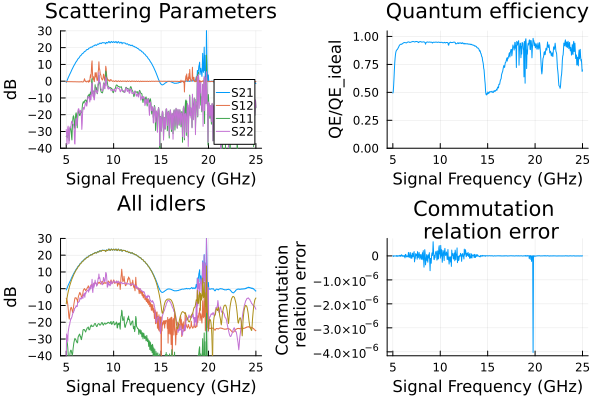

In [7]:
p1=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(
            outputmode=(0,),
            outputport=2,
            inputmode=(0,),
            inputport=1,
            freqindex=:),
    )),
    ylim=(-40,30),label="S21",
    xlabel="Signal Frequency (GHz)",
    legend=:bottomright,
    title="Scattering Parameters",
    ylabel="dB");

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),2,:))),
    label="S12",
    );

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),1,:))),
    label="S11",
    );

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),2,(0,),2,:))),
    label="S22",
    );

p2=plot(sol.linearized.w/(2*pi*1e9),
    sol.linearized.QE((0,),2,(0,),1,:)./sol.linearized.QEideal((0,),2,(0,),1,:),
    ylim=(0,1.05),
    title="Quantum efficiency",legend=false,
    ylabel="QE/QE_ideal",xlabel="Signal Frequency (GHz)");

p3=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(:,2,(0,),1,:)')),
    ylim=(-40,30),
    xlabel="Signal Frequency (GHz)",
    legend=false,
    title="All idlers",
    ylabel="dB");

p4=plot(sol.linearized.w/(2*pi*1e9),
    1 .- sol.linearized.CM((0,),2,:),
    legend=false,title="Commutation \n relation error",
    ylabel="Commutation \n relation error",xlabel="Signal Frequency (GHz)");

plot(p1, p2, p3, p4, layout = (2, 2))

# Same, but for the TFQ

In [8]:
alpha = 0.7
nr_cells = 10

Idc = 0*1e-6
Ip = 0

0

In [9]:
circuit = Tuple{String,String,String,Num}[]
entry = (elem, n1, n2, value) -> push!(circuit, ("$(elem)$(n1)_$(n2)", "$n1", "$n2", value))

function build_circuit()
    node = 1

    node_p1 = node # P1: Start of transmission line
    entry("P", node_p1, 0, 1)
    entry("R", node_p1, 0, Rport)

    node_p3 = node+1 # P3: Start of pump line
    entry("P", node_p3, 0, 3)
    entry("R", node_p3, 0, Rport)

    for cell_index in 1:nr_cells
        if cell_index == 1
            entry("C", node, 0, C/2)
        else
            entry("C", node, 0, C)
        end
        entry("Lj_a", node, node+6, Lj/alpha)
        entry("Cj_a", node, node+6, Cj*alpha)
        entry("L", node, node+2, Lsmall)
        entry("Lj_b", node+2, node+3, Lj)
        entry("Cj_b", node+2, node+3, Cj)
        entry("Lj_c", node+3, node+6, Lj)
        entry("Cj_c", node+3, node+6, Cj)
        entry("L", node, node+4, Lsmall)
        entry("Lj_d", node+4, node+5, Lj)
        entry("Cj_d", node+4, node+5, Cj)
        entry("Lj_e", node+5, node+6, Lj)
        entry("Cj_e", node+5, node+6, Cj)

        entry("L", node+1, node+7, Lpump)
        if cell_index == 1
            entry("C", node+1, 0, Cpump/2)
        else
            entry("C", node+1, 0, Cpump)
        end
        push!(circuit, ("K$(node)_1", "L$(node)_$(node+2)", "L$(node+1)_$(node+7)", kappa))
        push!(circuit, ("K$(node)_2", "L$(node)_$(node+4)", "L$(node+1)_$(node+7)", kappa))

        node += 6
    end

    entry("C", node, 0, C/2)
    entry("P", node, 0, 2) # P2: End of transmission line
    entry("R", node, 0, Rport)

    entry("C", node+1, 0, Cpump/2)
    entry("P", node+1, 0, 4) # P4: End of pump line
    entry("R", node+1, 0, Rport)
    entry("L", node+1, 0, Lg)

end

build_circuit()

181-element Vector{Tuple{String, String, String, Num}}:
 ("P1_0", "1", "0", 1)
 ("R1_0", "1", "0", Rport)
 ("P2_0", "2", "0", 3)
 ("R2_0", "2", "0", Rport)
 ("C1_0", "1", "0", (1//2)*C)
 ("Lj_a1_7", "1", "7", 1.4285714285714286Lj)
 ("Cj_a1_7", "1", "7", 0.7Cj)
 ("L1_3", "1", "3", Lsmall)
 ("Lj_b3_4", "3", "4", Lj)
 ("Cj_b3_4", "3", "4", Cj)
 ("Lj_c4_7", "4", "7", Lj)
 ("Cj_c4_7", "4", "7", Cj)
 ("L1_5", "1", "5", Lsmall)
 ⋮
 ("Cj_e60_61", "60", "61", Cj)
 ("L56_62", "56", "62", Lpump)
 ("C56_0", "56", "0", Cpump)
 ("K55_1", "L55_57", "L56_62", kappa)
 ("K55_2", "L55_59", "L56_62", kappa)
 ("C61_0", "61", "0", (1//2)*C)
 ("P61_0", "61", "0", 2)
 ("R61_0", "61", "0", Rport)
 ("C62_0", "62", "0", (1//2)*Cpump)
 ("P62_0", "62", "0", 4)
 ("R62_0", "62", "0", Rport)
 ("L62_0", "62", "0", Lg)

In [10]:
circuitdefs = Dict(
    kappa => 0.999, # the inverse inductance matrix for K=1.0 diverges, so set K<1.0
    Lg => 20.0e-9,  # inductance to ground, required for solver
    Rport => 50.0,
    C => capacitance,
    Lj => junction_inductance,
    Lpump => pump_line_inductance,
    Cpump => pump_line_inductance / transmission_line_impedance^2,
    Lsmall => linear_squid_loop_inductance,
    Cj => jj_capacitance,
)

Dict{Num, Float64} with 9 entries:
  Lg     => 2.0e-8
  Lpump  => 1.90294e-10
  C      => 6.91978e-14
  Cpump  => 7.61176e-14
  kappa  => 0.999
  Rport  => 50.0
  Cj     => 3.17068e-14
  Lj     => 1.72995e-10
  Lsmall => 6.91978e-14

Check pumping TWPA of the TFQ metamaterial

In [11]:
ws = 2*pi*signal_frequency
wp = (2*pi*pump_frequency,)

# add the DC bias and pump to port 3
sourcespumpon = [(mode=(0,),port=3,current=Idc),(mode=(1,),port=3,current=Ip)]
Npumpharmonics = (4,)
Nmodulationharmonics = (2,)
@time sol = hbsolve(ws, wp, sourcespumpon, Nmodulationharmonics,
    Npumpharmonics, circuit, circuitdefs;
    dc = true, threewavemixing=true,fourwavemixing=true,
    switchofflinesearchtol=0.0,alphamin=1e-7,iterations=200) # enable dc and three wave mixing

  1.406400 seconds (157.66 k allocations: 32.445 MiB, 1.78% gc time, 47.31% compilation time)


JosephsonCircuits.HB(JosephsonCircuits.NonlinearHB((1.2566370614359172e11,), JosephsonCircuits.Frequencies{1}((4,), (5,), (8,), CartesianIndex{1}[CartesianIndex(1,), CartesianIndex(2,), CartesianIndex(3,), CartesianIndex(4,), CartesianIndex(5,)], [(0,), (1,), (2,), (3,), (4,)]), ComplexF64[0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im], sparse([1, 21, 26, 31, 2, 22, 27, 32, 3, 23  …  16, 396, 17, 397, 18, 398, 19, 399, 20, 400], [1, 1, 1, 1, 2, 2, 2, 2, 3, 3  …  306, 306, 307, 307, 308, 308, 309, 309, 310, 310], [1, -1, -1, -1, 1, -1, -1, -1, 1, -1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 420, 310),   [7 ]  =  2.47135e-10
  [9 ]  =  1.72995e-10
  [10]  =  1.72995e-10
  [11]  =  1.72995e-10
  [12]  =  1.72995e-10
  [15]  =  2.47135e-10
  [17]  =  1.72995e-10
  [18]  =  1.72995e-10
  [19]  =  1.72995e-10
  [20]  =  1.72995e-10
        

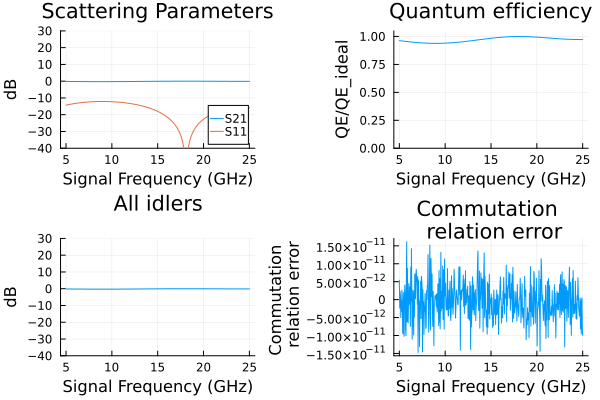

In [12]:
p1=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(
            outputmode=(0,),
            outputport=2,
            inputmode=(0,),
            inputport=1,
            freqindex=:),
    )),
    ylim=(-40,30),label="S21",
    xlabel="Signal Frequency (GHz)",
    legend=:bottomright,
    title="Scattering Parameters",
    ylabel="dB");

#plot!(sol.linearized.w/(2*pi*1e9),
#    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),2,:))),
#    label="S12",
#    );

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),1,:))),
    label="S11",
    );

#plot!(sol.linearized.w/(2*pi*1e9),
#    10*log10.(abs2.(sol.linearized.S((0,),2,(0,),2,:))),
#    label="S22",
#    );

p2=plot(sol.linearized.w/(2*pi*1e9),
    sol.linearized.QE((0,),2,(0,),1,:)./sol.linearized.QEideal((0,),2,(0,),1,:),
    ylim=(0,1.05),
    title="Quantum efficiency",legend=false,
    ylabel="QE/QE_ideal",xlabel="Signal Frequency (GHz)");

p3=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(:,2,(0,),1,:)')),
    ylim=(-40,30),
    xlabel="Signal Frequency (GHz)",
    legend=false,
    title="All idlers",
    ylabel="dB");

p4=plot(sol.linearized.w/(2*pi*1e9),
    1 .- sol.linearized.CM((0,),2,:),
    legend=false,title="Commutation \n relation error",
    ylabel="Commutation \n relation error",xlabel="Signal Frequency (GHz)");

plot(p1, p2, p3, p4, layout = (2, 2))

# No pumping, just biasing with constant field. Sweep the current

In [3]:
alpha = 0.26
nr_cells = 5

5

In [4]:
circuit = Tuple{String,String,String,Num}[]
entry = (elem, n1, n2, value) -> push!(circuit, ("$(elem)$(n1)_$(n2)", "$n1", "$n2", value))

function build_circuit()
    node = 1

    node_p1 = node # P1: Start of transmission line
    entry("P", node_p1, 0, 1)
    entry("R", node_p1, 0, Rport)

    node_p3 = node+1 # P3: Start of pump line
    entry("P", node_p3, 0, 3)
    entry("R", node_p3, 0, Rport)

    for cell_index in 1:nr_cells
        if cell_index == 1
            entry("C", node, 0, C/2)
        else
            entry("C", node, 0, C)
        end
        entry("Lj_a", node, node+6, Lj/alpha)
        entry("Cj_a", node, node+6, Cj*alpha)
        entry("L", node, node+2, Lsmall)
        entry("Lj_b", node+2, node+3, Lj)
        entry("Cj_b", node+2, node+3, Cj)
        entry("Lj_c", node+3, node+6, Lj)
        entry("Cj_c", node+3, node+6, Cj)
        entry("L", node, node+4, Lsmall)
        entry("Lj_d", node+4, node+5, Lj)
        entry("Cj_d", node+4, node+5, Cj)
        entry("Lj_e", node+5, node+6, Lj)
        entry("Cj_e", node+5, node+6, Cj)

        entry("L", node+1, node+7, Lpump)
        if cell_index == 1
            entry("C", node+1, 0, Cpump/2)
        else
            entry("C", node+1, 0, Cpump)
        end
        push!(circuit, ("K$(node)_1", "L$(node)_$(node+2)", "L$(node+1)_$(node+7)", kappa))
        push!(circuit, ("K$(node)_2", "L$(node)_$(node+4)", "L$(node+1)_$(node+7)", -kappa))

        node += 6
    end

    entry("C", node, 0, C/2)
    entry("P", node, 0, 2) # P2: End of transmission line
    entry("R", node, 0, Rport)

    entry("C", node+1, 0, Cpump/2)
    entry("P", node+1, 0, 4) # P4: End of pump line
    entry("R", node+1, 0, Rport)
    entry("L", node+1, 0, Lg)

end

build_circuit()

96-element Vector{Tuple{String, String, String, Num}}:
 ("P1_0", "1", "0", 1)
 ("R1_0", "1", "0", Rport)
 ("P2_0", "2", "0", 3)
 ("R2_0", "2", "0", Rport)
 ("C1_0", "1", "0", (1//2)*C)
 ("Lj_a1_7", "1", "7", 3.846153846153846Lj)
 ("Cj_a1_7", "1", "7", 0.26Cj)
 ("L1_3", "1", "3", Lsmall)
 ("Lj_b3_4", "3", "4", Lj)
 ("Cj_b3_4", "3", "4", Cj)
 ("Lj_c4_7", "4", "7", Lj)
 ("Cj_c4_7", "4", "7", Cj)
 ("L1_5", "1", "5", Lsmall)
 ⋮
 ("Cj_e30_31", "30", "31", Cj)
 ("L26_32", "26", "32", Lpump)
 ("C26_0", "26", "0", Cpump)
 ("K25_1", "L25_27", "L26_32", kappa)
 ("K25_2", "L25_29", "L26_32", -kappa)
 ("C31_0", "31", "0", (1//2)*C)
 ("P31_0", "31", "0", 2)
 ("R31_0", "31", "0", Rport)
 ("C32_0", "32", "0", (1//2)*Cpump)
 ("P32_0", "32", "0", 4)
 ("R32_0", "32", "0", Rport)
 ("L32_0", "32", "0", Lg)

In [5]:
circuitdefs = Dict(
    kappa => 0.999, # the inverse inductance matrix for K=1.0 diverges, so set K<1.0
    Lg => 20.0e-9,  # inductance to ground, required for solver
    Rport => 50.0,
    C => capacitance,
    Lj => junction_inductance,
    Lpump => pump_line_inductance,
    Cpump => pump_line_inductance / transmission_line_impedance^2,
    Lsmall => linear_squid_loop_inductance,
    Cj => jj_capacitance,
)

Dict{Num, Float64} with 9 entries:
  Lg     => 2.0e-8
  Lpump  => 1.90294e-10
  C      => 6.91978e-14
  Cpump  => 7.61176e-14
  kappa  => 0.999
  Rport  => 50.0
  Cj     => 3.17068e-14
  Lj     => 1.72995e-10
  Lsmall => 6.91978e-14

In [6]:
ws = 2*pi*signal_frequency
wp = (2*pi*0.00*1e9,)
Ip = 0.0*1e-6
Is = 0.0*1e-6
currentvals = (200:50:1000)*1e-6
outvals_S21 = zeros(Complex{Float64},length(ws),length(currentvals))
outvals_S11 = zeros(Complex{Float64},length(ws),length(currentvals))
        
Npumpharmonics = (4,)
Nmodulationharmonics = (2,)
        

@time for (k,Idc) in enumerate(currentvals)
    println("Current: $(round(Idc*1e6, digits = 1)) mkA")  
    sources = [
          (mode=(0,),port=3,current=Idc),
          (mode=(1,),port=3,current=Ip),
          (mode=(1,),port=1,current=Is),
      ]
    
    sol = hbsolve(ws,wp,sources,Nmodulationharmonics, Npumpharmonics,
        circuit, circuitdefs;dc=true,threewavemixing=true,fourwavemixing=true,
        switchofflinesearchtol=0.0,alphamin=1e-7,iterations=200) # enable dc and three wave mixing)
    outvals_S21[:,k] = sol.linearized.S((0,),2,(0,),1,:)
    outvals_S11[:,k] = sol.linearized.S((0,),1,(0,),1,:)
end

Current: 200.0 mkA
Current: 250.0 mkA
Current: 300.0 mkA
Current: 350.0 mkA
Current: 400.0 mkA
Current: 450.0 mkA
Current: 500.0 mkA
Current: 550.0 mkA
Current: 600.0 mkA
Current: 650.0 mkA
Current: 700.0 mkA
Current: 750.0 mkA
Current: 800.0 mkA
Current: 850.0 mkA
Current: 900.0 mkA
Current: 950.0 mkA
Current: 1000.0 mkA
 12.911000 seconds (6.17 M allocations: 710.976 MiB, 4.74% gc time, 60.91% compilation time: 9% of which was recompilation)


S-parameter

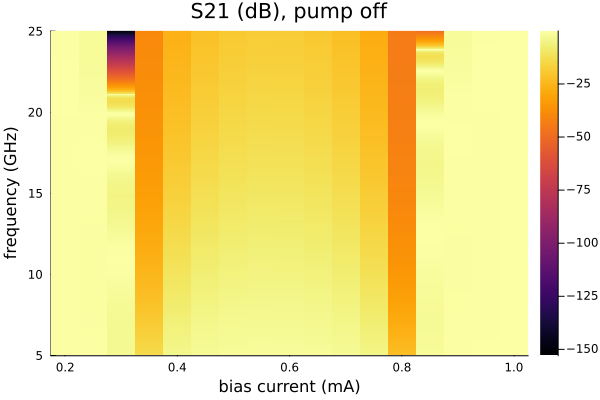

In [7]:
plot(
    currentvals/(1e-3),
    ws/(2*pi*1e9),
    10*log10.(abs2.(outvals_S21)),
    seriestype=:heatmap,
    xlabel="bias current (mA)",
    ylabel="frequency (GHz)",
    title="S21 (dB), pump off",
)

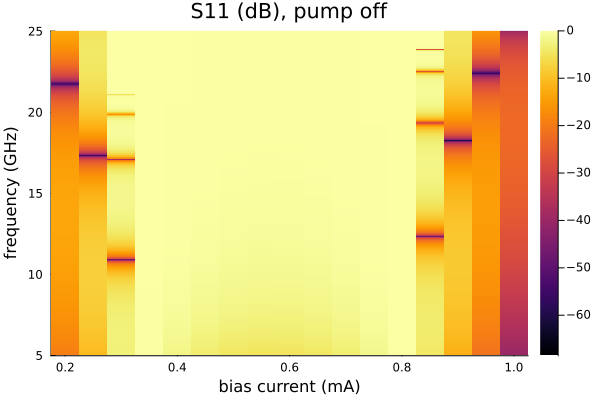

In [8]:
plot(
    currentvals/(1e-3),
    ws/(2*pi*1e9),
    10*log10.(abs2.(outvals_S11)),
    seriestype=:heatmap,
    xlabel="bias current (mA)",
    ylabel="frequency (GHz)",
    title="S11 (dB), pump off",
)

# Chain of SNAILs

In [31]:
nr_cells = 50

alpha = 0.29

optimal_dc_flux = magnetic_flux_quantum * 0.41
Idc = optimal_dc_flux / mutual_inductance
Ip = modulation_parameter * Idc                 #pump current

1.4702407210616366e-5

In [32]:
circuit = Tuple{String,String,String,Num}[]
entry = (elem, n1, n2, value) -> push!(circuit, ("$(elem)$(n1)_$(n2)", "$n1", "$n2", value))

function build_circuit()
    node = 1

    node_p1 = node # P1: Start of transmission line
    entry("P", node_p1, 0, 1)
    entry("R", node_p1, 0, Rport)

    node_p3 = node+1 # P3: Start of pump line
    entry("P", node_p3, 0, 3)
    entry("R", node_p3, 0, Rport)

    for cell_index in 1:nr_cells
        if cell_index == 1
            entry("C", node, 0, C/2)
        else
            entry("C", node, 0, C)
        end
        entry("Lj_a", node, node+5, Lj/alpha)
        entry("Cj_a", node, node+5, Cj*alpha)
        entry("L", node, node+2, Lsmall)
        entry("Lj_b", node+2, node+3, Lj)
        entry("Cj_b", node+2, node+3, Cj)
        entry("Lj_c", node+3, node+4, Lj)
        entry("Cj_c", node+3, node+4, Cj)
        entry("Lj_d", node+4, node+5, Lj)
        entry("Cj_d", node+4, node+5, Cj)

        entry("L", node+1, node+6, Lpump)
        if cell_index == 1
            entry("C", node+1, 0, Cpump/2)
        else
            entry("C", node+1, 0, Cpump)
        end
        push!(circuit, ("K$(node)", "L$(node)_$(node+2)", "L$(node+1)_$(node+6)", kappa))
        
        node += 5
    end

    entry("C", node, 0, C/2)
    entry("P", node, 0, 2) # P2: End of transmission line
    entry("R", node, 0, Rport)

    entry("C", node+1, 0, Cpump/2)
    entry("P", node+1, 0, 4) # P4: End of pump line
    entry("R", node+1, 0, Rport)
    entry("L", node+1, 0, Lg)

end

build_circuit()

661-element Vector{Tuple{String, String, String, Num}}:
 ("P1_0", "1", "0", 1)
 ("R1_0", "1", "0", Rport)
 ("P2_0", "2", "0", 3)
 ("R2_0", "2", "0", Rport)
 ("C1_0", "1", "0", (1//2)*C)
 ("Lj_a1_6", "1", "6", 3.4482758620689657Lj)
 ("Cj_a1_6", "1", "6", 0.29Cj)
 ("L1_3", "1", "3", Lsmall)
 ("Lj_b3_4", "3", "4", Lj)
 ("Cj_b3_4", "3", "4", Cj)
 ("Lj_c4_5", "4", "5", Lj)
 ("Cj_c4_5", "4", "5", Cj)
 ("Lj_d5_6", "5", "6", Lj)
 ⋮
 ("Lj_d250_251", "250", "251", Lj)
 ("Cj_d250_251", "250", "251", Cj)
 ("L247_252", "247", "252", Lpump)
 ("C247_0", "247", "0", Cpump)
 ("K246", "L246_248", "L247_252", kappa)
 ("C251_0", "251", "0", (1//2)*C)
 ("P251_0", "251", "0", 2)
 ("R251_0", "251", "0", Rport)
 ("C252_0", "252", "0", (1//2)*Cpump)
 ("P252_0", "252", "0", 4)
 ("R252_0", "252", "0", Rport)
 ("L252_0", "252", "0", Lg)

In [33]:
circuitdefs = Dict(
    kappa => 0.999, # the inverse inductance matrix for K=1.0 diverges, so set K<1.0
    Lg => 20.0e-9,  # inductance to ground, required for solver
    Rport => 50.0,
    C => capacitance,
    Lj => junction_inductance,
    Lpump => pump_line_inductance,
    Cpump => pump_line_inductance / transmission_line_impedance^2,
    Lsmall => linear_squid_loop_inductance,
    Cj => jj_capacitance,
)

Dict{Num, Float64} with 9 entries:
  Lg     => 2.0e-8
  Lpump  => 1.90294e-10
  C      => 6.91978e-14
  Cpump  => 7.61176e-14
  kappa  => 0.999
  Rport  => 50.0
  Cj     => 3.17068e-14
  Lj     => 1.72995e-10
  Lsmall => 6.91978e-14

In [34]:
ws = 2*pi*signal_frequency
wp = (2*pi*pump_frequency,)

# add the DC bias and pump to port 3
sourcespumpon = [(mode=(0,),port=3,current=Idc),(mode=(1,),port=3,current=Ip)]
Npumpharmonics = (4,)
Nmodulationharmonics = (2,)
@time sol = hbsolve(ws, wp, sourcespumpon, Nmodulationharmonics,
    Npumpharmonics, circuit, circuitdefs;
    dc = true, threewavemixing=true,fourwavemixing=true,
    switchofflinesearchtol=0.0,alphamin=1e-7,iterations=200) # enable dc and three wave mixing

  2.337564 seconds (51.87 k allocations: 58.278 MiB, 0.69% gc time)


JosephsonCircuits.HB(JosephsonCircuits.NonlinearHB((1.2566370614359172e11,), JosephsonCircuits.Frequencies{1}((4,), (5,), (8,), CartesianIndex{1}[CartesianIndex(1,), CartesianIndex(2,), CartesianIndex(3,), CartesianIndex(4,), CartesianIndex(5,)], [(0,), (1,), (2,), (3,), (4,)]), ComplexF64[116.86505007757056 - 15.835454230498705im 21975.26659037943 - 7.681008942105906e-5im … 23.267285335608257 - 14.571317216111474im 14891.259231800686 + 4.476544098275956e-8im; 0.026367975195347174 - 0.012458135844732822im -0.15529513742928736 - 8.988647174436634im … -0.04383975113297862 + 0.10296866697294216im 7.467716861340422 - 4.8139474408618375im; … ; 0.00012240968765335223 - 9.8939974814357e-5im 2.8663203636904045e-6 - 2.683788389567722e-7im … 2.3679635398811896e-5 + 0.00020232441727618402im 2.3969994787778067e-6 - 1.1177262059727148e-6im; 8.125155979804305e-7 + 7.838169817168931e-7im 2.2832304129999095e-6 + 5.397563070029319e-6im … 5.3116043272862025e-6 + 4.1133819294767214e-6im 2.115436846979435

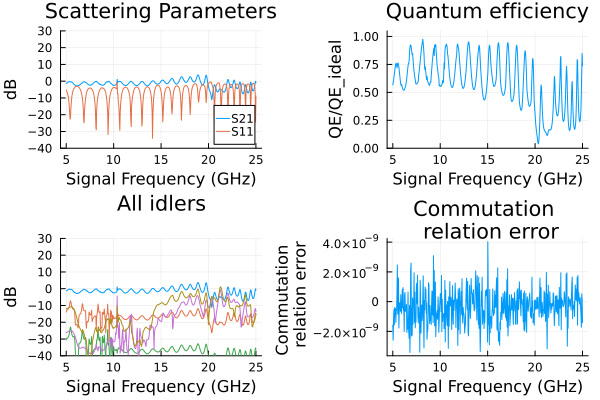

In [35]:
p1=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(
            outputmode=(0,),
            outputport=2,
            inputmode=(0,),
            inputport=1,
            freqindex=:),
    )),
    ylim=(-40,30),label="S21",
    xlabel="Signal Frequency (GHz)",
    legend=:bottomright,
    title="Scattering Parameters",
    ylabel="dB");

#plot!(sol.linearized.w/(2*pi*1e9),
#    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),2,:))),
#    label="S12",
#    );

plot!(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S((0,),1,(0,),1,:))),
    label="S11",
    );

#plot!(sol.linearized.w/(2*pi*1e9),
#    10*log10.(abs2.(sol.linearized.S((0,),2,(0,),2,:))),
#    label="S22",
#    );

p2=plot(sol.linearized.w/(2*pi*1e9),
    sol.linearized.QE((0,),2,(0,),1,:)./sol.linearized.QEideal((0,),2,(0,),1,:),
    ylim=(0,1.05),
    title="Quantum efficiency",legend=false,
    ylabel="QE/QE_ideal",xlabel="Signal Frequency (GHz)");

p3=plot(sol.linearized.w/(2*pi*1e9),
    10*log10.(abs2.(sol.linearized.S(:,2,(0,),1,:)')),
    ylim=(-40,30),
    xlabel="Signal Frequency (GHz)",
    legend=false,
    title="All idlers",
    ylabel="dB");

p4=plot(sol.linearized.w/(2*pi*1e9),
    1 .- sol.linearized.CM((0,),2,:),
    legend=false,title="Commutation \n relation error",
    ylabel="Commutation \n relation error",xlabel="Signal Frequency (GHz)");

plot(p1, p2, p3, p4, layout = (2, 2))

# No Pump S21

In [29]:
ws = 2*pi*signal_frequency
wp = (2*pi*0.00*1e9,)
Ip = 0.0*1e-6
Is = 0.0*1e-6
currentvals = (0:1:1000)*1e-6
outvals_S21 = zeros(Complex{Float64},length(ws),length(currentvals))
outvals_S11 = zeros(Complex{Float64},length(ws),length(currentvals))
        
Npumpharmonics = (4,)
Nmodulationharmonics = (2,)
        

@time for (k,Idc) in enumerate(currentvals)
    println("Current: $(round(Idc*1e6, digits = 1)) mkA")  
    sources = [
          (mode=(0,),port=3,current=Idc),
          (mode=(1,),port=3,current=Ip),
          (mode=(1,),port=1,current=Is),
      ]
    
    sol = hbsolve(ws,wp,sources,Nmodulationharmonics, Npumpharmonics,
        circuit, circuitdefs;dc=true,threewavemixing=true,fourwavemixing=true,
        switchofflinesearchtol=0.0,alphamin=1e-7,iterations=200) # enable dc and three wave mixing)
    outvals_S21[:,k] = sol.linearized.S((0,),2,(0,),1,:)
    outvals_S11[:,k] = sol.linearized.S((0,),1,(0,),1,:)
end

Current: 0.0 mkA
Current: 1.0 mkA
Current: 2.0 mkA
Current: 3.0 mkA
Current: 4.0 mkA
Current: 5.0 mkA
Current: 6.0 mkA
Current: 7.0 mkA
Current: 8.0 mkA
Current: 9.0 mkA
Current: 10.0 mkA


LoadError: InterruptException:

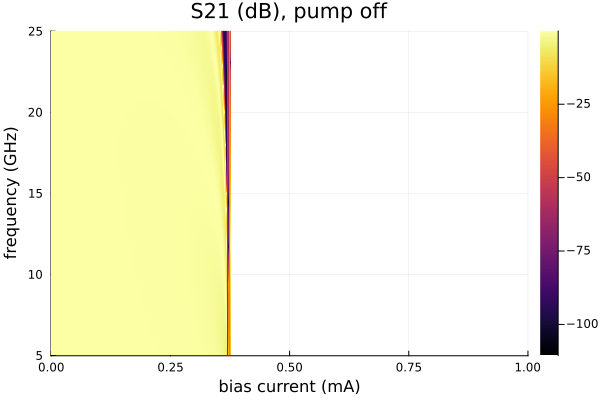

In [17]:
plot(
    currentvals/(1e-3),
    ws/(2*pi*1e9),
    10*log10.(abs2.(outvals_S21)),
    seriestype=:heatmap,
    xlabel="bias current (mA)",
    ylabel="frequency (GHz)",
    title="S21 (dB), pump off",
)

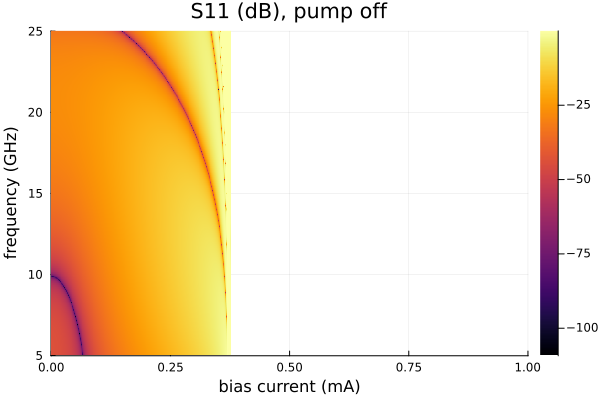

In [18]:
plot(
    currentvals/(1e-3),
    ws/(2*pi*1e9),
    10*log10.(abs2.(outvals_S11)),
    seriestype=:heatmap,
    xlabel="bias current (mA)",
    ylabel="frequency (GHz)",
    title="S11 (dB), pump off",
)